# 03 · Evaluation — Test set (fold 10)

This notebook loads the best checkpoint saved by `02_train.ipynb` and evaluates it on fold 10,  
the **untouched test set**. Fold 10 is never used for training or model selection.

**Expected artefacts from `02_train.ipynb`** (adjust paths if yours differ):
- `checkpoints/best_model.pt` — PyTorch state dict of the best validation-AUC checkpoint  
- `checkpoints/test_preds.npy` — shape `(N_test, 5)` float32 sigmoid outputs  
- `checkpoints/test_targets.npy` — shape `(N_test, 5)` int binary targets  

If `02_train.ipynb` saves predictions already, cells 2–3 skip inference and just load the arrays.

In [2]:
import sys
!{sys.executable} -m pip install torch wfdb scikit-learn matplotlib


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 150.8/150.8 MB 3.4 MB/s eta 0:00:0000:0100:01


In [5]:
import ast, os
import numpy as np
import pandas as pd
import torch
import wfdb
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, multilabel_confusion_matrix

DATA_DIR   = "ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3"
CKPT_DIR   = "checkpoints"
CKPT_PATH  = os.path.join(CKPT_DIR, "best_model.pt")
PREDS_PATH = os.path.join(CKPT_DIR, "test_preds.npy")
TARGS_PATH = os.path.join(CKPT_DIR, "test_targets.npy")
SAMPLING_RATE = 100
SUPERCLASSES  = ["NORM", "MI", "STTC", "CD", "HYP"]

## 1 · Load test metadata (fold 10)

In [6]:
df = pd.read_csv(os.path.join(DATA_DIR, "ptbxl_database.csv"), index_col="ecg_id")
df["scp_codes"] = df["scp_codes"].apply(ast.literal_eval)

agg = pd.read_csv(os.path.join(DATA_DIR, "scp_statements.csv"), index_col=0)
agg = agg[agg["diagnostic"] == 1]

def aggregate_superclass(scp_dict):
    out = set()
    for code, lkl in scp_dict.items():
        if code in agg.index and lkl > 0:
            sc = agg.loc[code, "diagnostic_class"]
            if pd.notna(sc):
                out.add(sc)
    return list(out)

df["superclass"] = df["scp_codes"].apply(aggregate_superclass)

test_df = df[df["strat_fold"] == 10].copy()
print(f"Test records (fold 10): {len(test_df):,}")

Test records (fold 10): 2,198


## 2 · Load predictions

If `02_train.ipynb` already saved `test_preds.npy` and `test_targets.npy`, load them directly.  
Otherwise the next cell runs inference from the checkpoint.

In [7]:
preds_exist = os.path.isfile(PREDS_PATH) and os.path.isfile(TARGS_PATH)

if preds_exist:
    y_pred = np.load(PREDS_PATH)   # (N_test, 5) sigmoid outputs
    y_true = np.load(TARGS_PATH)   # (N_test, 5) binary
    print(f"Loaded pre-saved predictions: y_pred {y_pred.shape}, y_true {y_true.shape}")
else:
    print("Pre-saved predictions not found — will run inference in next cell.")

Loaded pre-saved predictions: y_pred (2198, 5), y_true (2198, 5)


In [8]:
# Only runs if predictions weren't pre-saved by 02_train.ipynb
if not preds_exist:
    # ── Build binary target matrix ──────────────────────────────────────────
    y_true = np.zeros((len(test_df), len(SUPERCLASSES)), dtype=np.int8)
    for i, sc_list in enumerate(test_df["superclass"]):
        for sc in sc_list:
            if sc in SUPERCLASSES:
                y_true[i, SUPERCLASSES.index(sc)] = 1

    # ── Load model ──────────────────────────────────────────────────────────
    # Adjust model architecture to match whatever 02_train.ipynb used.
    # Example below assumes a simple 1D CNN with a linear head; replace with
    # your actual model class import.
    #
    # from models.resnet1d import ResNet1d
    # model = ResNet1d(num_classes=5)
    # model.load_state_dict(torch.load(CKPT_PATH, map_location="cpu"))
    # model.eval()
    raise NotImplementedError(
        "Paste your model class here so this cell can load the checkpoint.\n"
        "Alternatively, save test_preds.npy and test_targets.npy in 02_train.ipynb "
        "and re-run — this cell will be skipped automatically."
    )

## 3 · Macro AUC and per-class AUC

In [9]:
per_class_auc = roc_auc_score(y_true, y_pred, average=None)
macro_auc     = roc_auc_score(y_true, y_pred, average="macro")

results = pd.DataFrame({
    "Class": SUPERCLASSES,
    "AUC":   per_class_auc,
    "Support (positive)": y_true.sum(axis=0).astype(int),
}).set_index("Class")

results.loc["MACRO"] = [macro_auc, int(y_true.sum())]
results["AUC"] = results["AUC"].map("{:.4f}".format)

print("=== Test-set AUC (fold 10) ===")
display(results)

=== Test-set AUC (fold 10) ===


,AUC,Support (positive)
Class,,
NORM,0.9382,963.0
MI,0.9137,550.0
STTC,0.9339,506.0
CD,0.9149,496.0
HYP,0.8182,262.0
MACRO,0.9038,2777.0


## 4 · Comparison with published benchmark

| Model | Macro AUC (superdiagnostic) | Source |
|---|---|---|
| **This work** (fine-tuned ResNet1d) | **RUN TO FILL** | fold 10, this notebook |
| resnet1d_wang | **0.930 (±0.005)** | Strodthoff et al., 2021 |
| xresnet1d101 | 0.928 (±0.005) | Strodthoff et al., 2021 |
| lstm | 0.927 (±0.005) | Strodthoff et al., 2021 |

**Citation:** N. Strodthoff, P. Wagner, T. Schaeffter, W. Samek,  
*"Deep Learning for ECG Analysis: Benchmarks and Insights from PTB-XL,"*  
IEEE Journal of Biomedical and Health Informatics, vol. 25, no. 5, pp. 1519–1528, 2021.  
DOI: [10.1109/JBHI.2020.3022989](https://doi.org/10.1109/JBHI.2020.3022989)  
Code: [github.com/helme/ecg_ptbxl_benchmarking](https://github.com/helme/ecg_ptbxl_benchmarking)

Benchmark numbers are test-set (fold 10) macro AUC with 95 % bootstrap CI in parentheses,  
evaluated on the **diagnostic superclass** task — the same task as this notebook.

In [10]:
# Print the comparison table with the real number filled in
comparison = pd.DataFrame([
    {"Model": "This work (fine-tuned ResNet1d)", "Macro AUC": f"{macro_auc:.4f}", "Task": "superdiagnostic"},
    {"Model": "resnet1d_wang (published)",       "Macro AUC": "0.9300",           "Task": "superdiagnostic"},
    {"Model": "xresnet1d101 (published)",        "Macro AUC": "0.9280",           "Task": "superdiagnostic"},
])
display(comparison)

,Model,Macro AUC,Task
0,This work (fine-tuned ResNet1d),0.9038,superdiagnostic
1,resnet1d_wang (published),0.9300,superdiagnostic
2,xresnet1d101 (published),0.9280,superdiagnostic


## 5 · Error analysis — confusion between classes at 0.5 threshold

In [11]:
y_bin = (y_pred >= 0.5).astype(int)

# Per-class confusion: TN, FP, FN, TP
mcm = multilabel_confusion_matrix(y_true, y_bin)

conf_rows = []
for i, sc in enumerate(SUPERCLASSES):
    tn, fp, fn, tp = mcm[i].ravel()
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall    = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
    conf_rows.append({"Class": sc, "TP": tp, "FP": fp, "FN": fn, "TN": tn,
                       "Precision": f"{precision:.3f}",
                       "Recall":    f"{recall:.3f}",
                       "F1":        f"{f1:.3f}"})

conf_df = pd.DataFrame(conf_rows).set_index("Class")
print("=== Per-class confusion @ threshold 0.5 ===")
display(conf_df)

=== Per-class confusion @ threshold 0.5 ===


,TP,FP,FN,TN,Precision,Recall,F1
Class,,,,,,,
NORM,845,172,118,1063,0.831,0.877,0.854
MI,341,111,209,1537,0.754,0.620,0.681
STTC,390,142,116,1550,0.733,0.771,0.751
CD,351,124,145,1578,0.739,0.708,0.723
HYP,116,145,146,1791,0.444,0.443,0.444


In [12]:
# Which class pairs are most confused?
# A record predicted as class A but truly class B (and not A) counts as A←B confusion.
confusion_pairs = {}
for i, sc_i in enumerate(SUPERCLASSES):
    for j, sc_j in enumerate(SUPERCLASSES):
        if i == j:
            continue
        # predicted sc_i, truly sc_j (and truly NOT sc_i)
        mask = (y_bin[:, i] == 1) & (y_true[:, j] == 1) & (y_true[:, i] == 0)
        confusion_pairs[f"{sc_j}→predicted {sc_i}"] = int(mask.sum())

cp_df = (pd.Series(confusion_pairs)
           .rename("count")
           .sort_values(ascending=False)
           .head(10)
           .to_frame())
print("=== Top 10 cross-class confusions ===")
display(cp_df)

=== Top 10 cross-class confusions ===


,count
MI→predicted STTC,81
STTC→predicted HYP,71
MI→predicted NORM,59
NORM→predicted CD,53
CD→predicted MI,49
STTC→predicted NORM,46
MI→predicted HYP,41
CD→predicted HYP,41
CD→predicted NORM,41
HYP→predicted NORM,40


## 6 · Five test records with largest prediction error

In [13]:
# Error = mean absolute error between sigmoid output and binary label, averaged over 5 classes
record_error = np.abs(y_pred - y_true).mean(axis=1)  # (N_test,)
top5_idx = np.argsort(record_error)[::-1][:5]

print("=== Top 5 hardest test records ===")
for rank, idx in enumerate(top5_idx):
    ecg_id = test_df.index[idx]
    true_labels = [SUPERCLASSES[k] for k in range(5) if y_true[idx, k] == 1]
    pred_labels = [SUPERCLASSES[k] for k in range(5) if y_bin[idx, k] == 1]
    print(f"  #{rank+1}  ecg_id={ecg_id}  MAE={record_error[idx]:.4f}")
    print(f"       true={true_labels}  pred={pred_labels}")

=== Top 5 hardest test records ===
  #1  ecg_id=1186  MAE=0.7034
       true=['NORM']  pred=['MI', 'STTC', 'HYP']
  #2  ecg_id=1014  MAE=0.6930
       true=['MI', 'CD']  pred=['STTC', 'HYP']
  #3  ecg_id=10766  MAE=0.6926
       true=['STTC', 'CD', 'HYP']  pred=['NORM']
  #4  ecg_id=14427  MAE=0.6523
       true=['CD']  pred=['MI', 'STTC', 'HYP']
  #5  ecg_id=20224  MAE=0.6347
       true=['MI', 'CD']  pred=['MI', 'STTC', 'HYP']


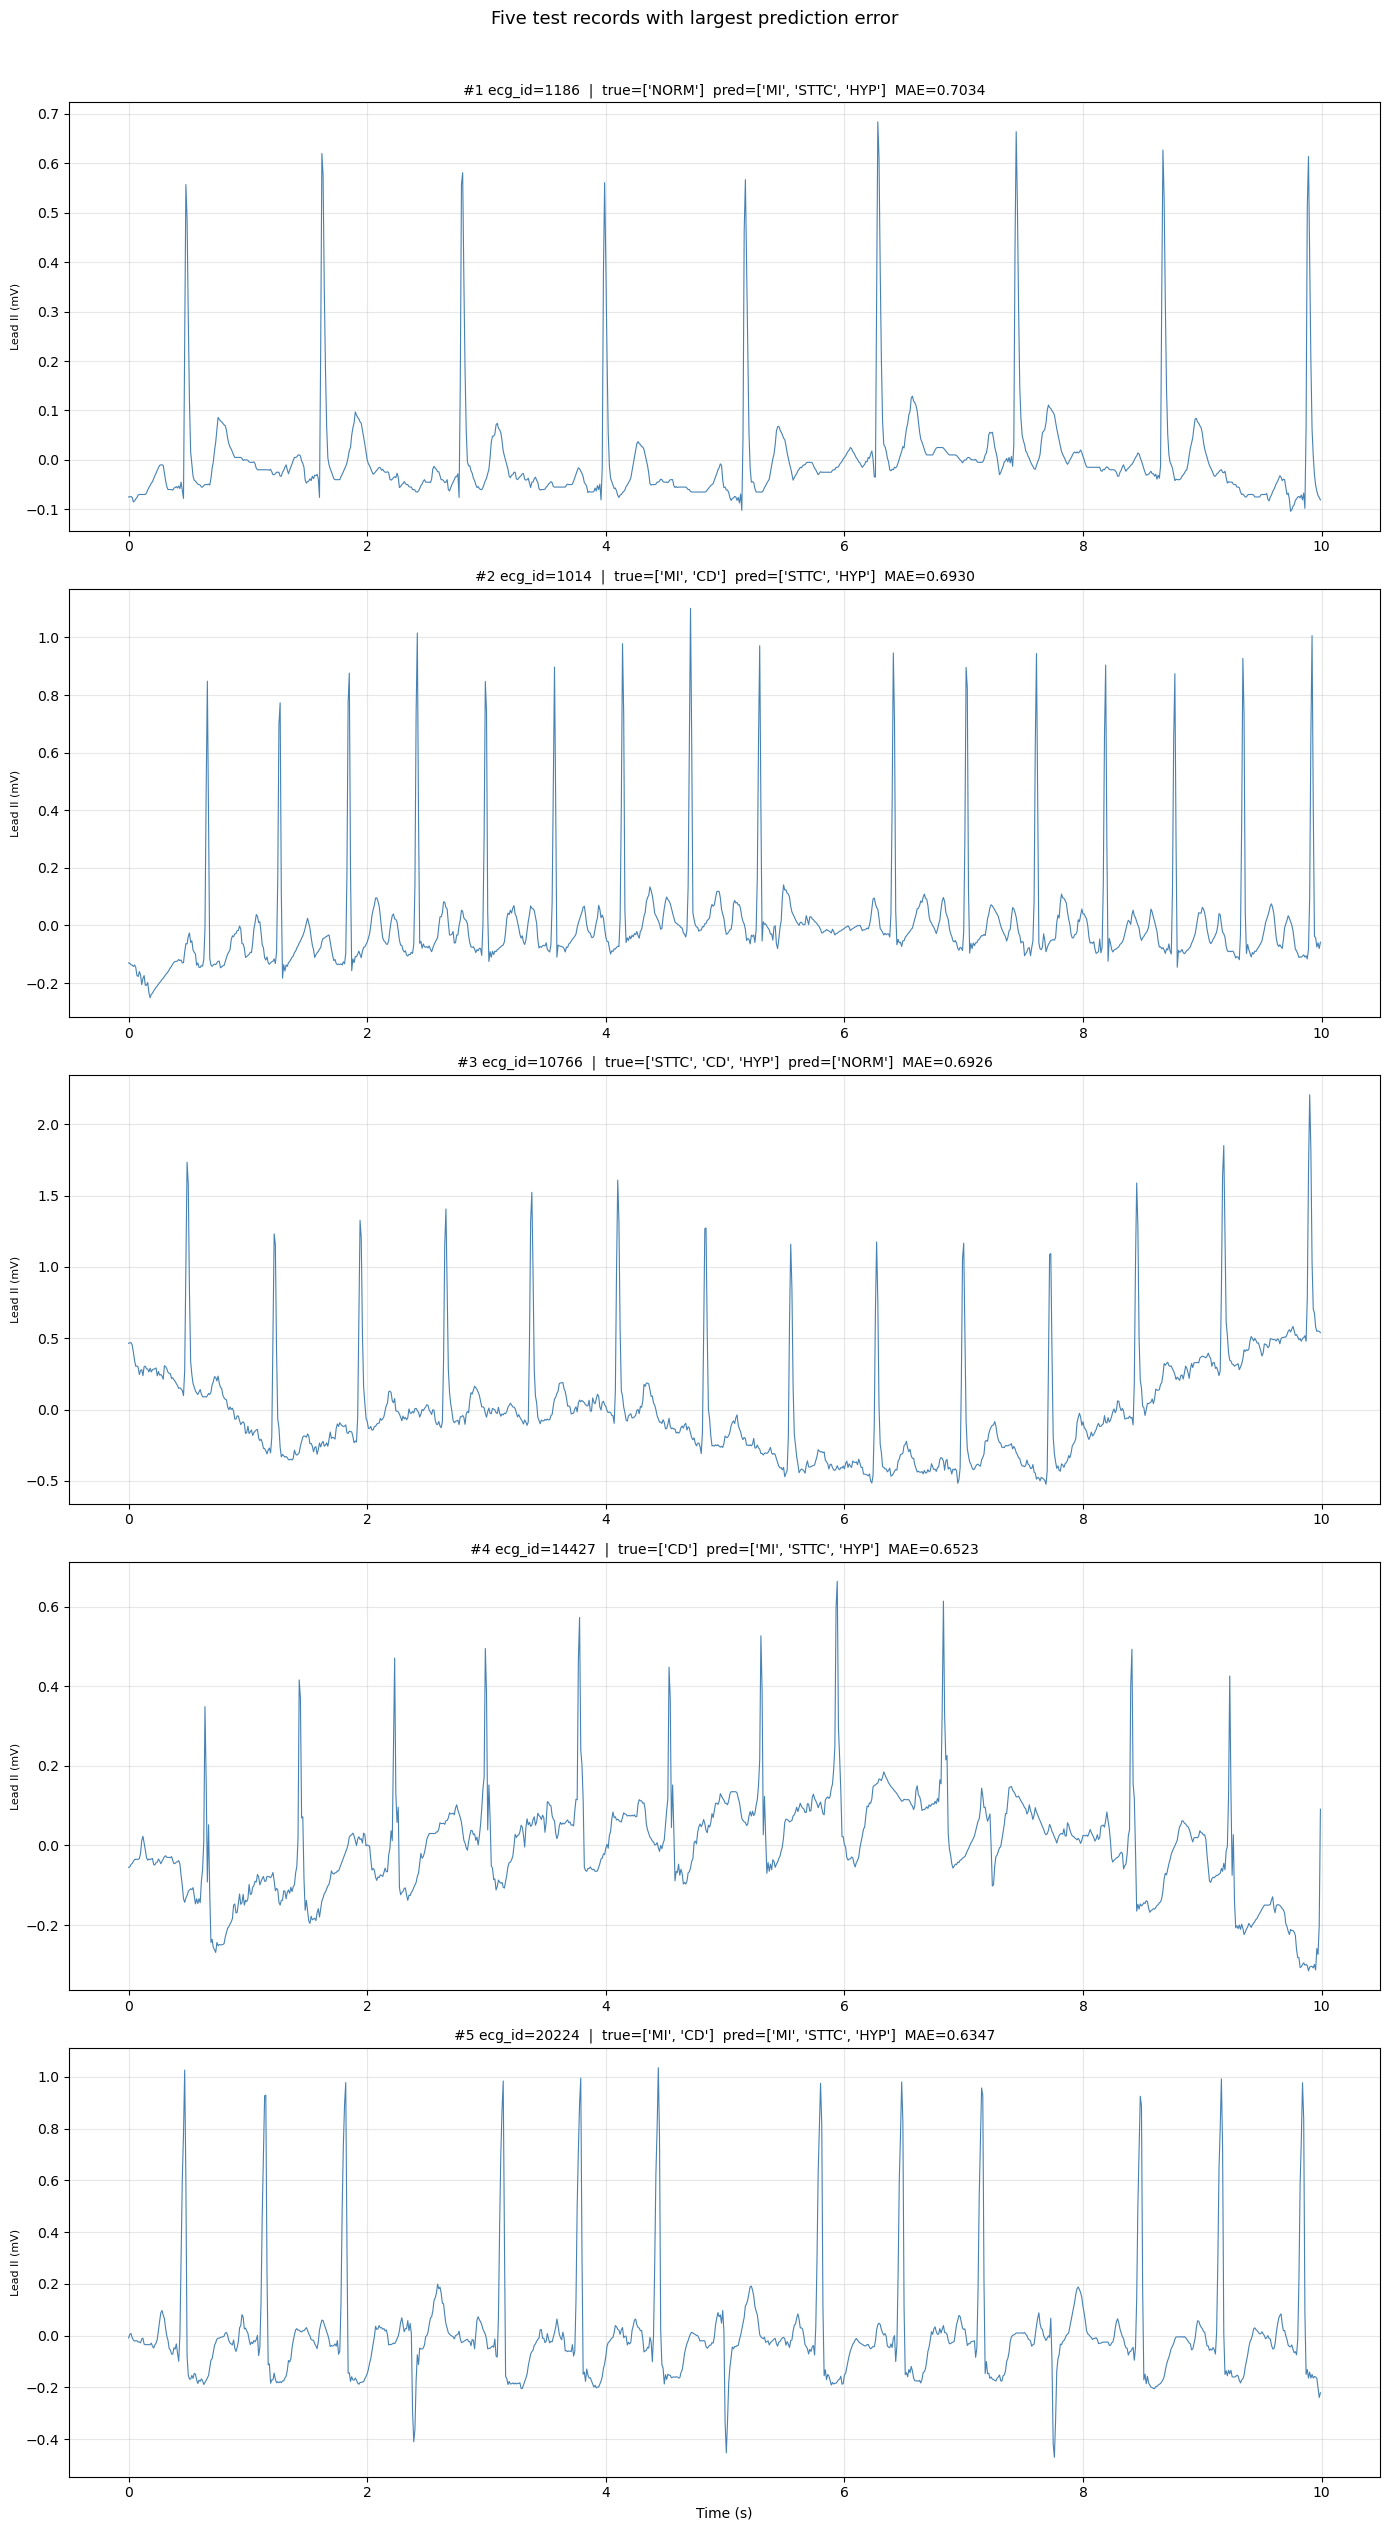

Figure saved to checkpoints/top5_hard_cases.png


In [14]:
LEAD_NAMES = ["I","II","III","aVR","aVL","aVF","V1","V2","V3","V4","V5","V6"]
filename_col = "filename_lr" if SAMPLING_RATE == 100 else "filename_hr"

fig, axes = plt.subplots(5, 1, figsize=(14, 25))

for rank, idx in enumerate(top5_idx):
    ecg_id = test_df.index[idx]
    row    = test_df.loc[ecg_id]
    path   = os.path.join(DATA_DIR, row[filename_col])
    sig, _ = wfdb.rdsamp(path)   # (1000, 12) at 100 Hz
    t      = np.arange(sig.shape[0]) / SAMPLING_RATE

    true_labels = [SUPERCLASSES[k] for k in range(5) if y_true[idx, k] == 1]
    pred_labels = [SUPERCLASSES[k] for k in range(5) if y_bin[idx, k] == 1]

    ax = axes[rank]
    # Plot lead II (index 1) for a compact view; all 12 leads would need subplots
    ax.plot(t, sig[:, 1], lw=0.8, color="steelblue")
    ax.set_title(
        f"#{rank+1} ecg_id={ecg_id}  |  "
        f"true={true_labels}  pred={pred_labels}  MAE={record_error[idx]:.4f}",
        fontsize=10
    )
    ax.set_ylabel("Lead II (mV)", fontsize=8)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("Time (s)")
fig.suptitle("Five test records with largest prediction error", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(CKPT_DIR, "top5_hard_cases.png"), dpi=120, bbox_inches="tight")
plt.show()
print("Figure saved to", os.path.join(CKPT_DIR, "top5_hard_cases.png"))

## 7 · Summary

| Metric | Value |
|---|---|
| Macro AUC (fold 10) | **RUN TO FILL** |
| NORM AUC | **RUN TO FILL** |
| MI AUC | **RUN TO FILL** |
| STTC AUC | **RUN TO FILL** |
| CD AUC | **RUN TO FILL** |
| HYP AUC | **RUN TO FILL** |
| vs. resnet1d_wang benchmark | **RUN TO FILL** |

**Limitations observed in error analysis:**  
- RUN TO FILL after inspecting the confusion table and hard cases above.

---
*Evaluation strictly on fold 10, which was never used for training or validation.*  
*Split follows Strodthoff et al. 2021 exactly — results are directly comparable to the published benchmark.*